<a href="https://colab.research.google.com/github/Sanjib521/codeAlpha_tasks/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install Required Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load  data set

In [ ]:
data = pd.read_csv('/content/train.csv')

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print(data.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


check for missing value

In [ ]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
handle missing value

In [ ]:
data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_40852/2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


#Convert Categorical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = encoder.fit_transform(data[column])

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


#Create new useful feature

In [ ]:
data['TotalIncome'] = (
    data['ApplicantIncome']
    + data['CoapplicantIncome']
)

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1,5849.0
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [ ]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,1
Loan_Amount_Term,0


In [ ]:
data['LoanAmount'].fillna(
    data['LoanAmount'].mean(),
    inplace=True
)

/tmp/ipykernel_40852/258225840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LoanAmount'].fillna(


In [ ]:
X = data.drop("Loan_Status", axis=1)

y = data["Loan_Status"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained")

Logistic Regression Model Trained


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lr_pred = lr_model.predict(X_test)

print(lr_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


#Required Parameter check

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.8130081300813008
Precision: 0.7821782178217822
Recall: 0.9875
F1 Score: 0.8729281767955801
ROC-AUC: 0.7379360465116279

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.49      0.65        43
           1       0.78      0.99      0.87        80

    accuracy                           0.81       123
   macro avg       0.87      0.74      0.76       123
weighted avg       0.84      0.81      0.79       123



#Train decesion tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7154471544715447


#Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7886178861788617


#Compare All Models

In [ ]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8130081300813008
Decision Tree Accuracy: 0.7154471544715447
Random Forest Accuracy: 0.7886178861788617


#Confusion Matrix Visualization

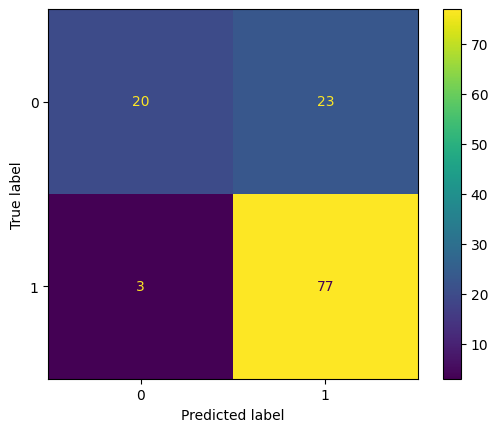

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.show()

#Feature Importance Graph

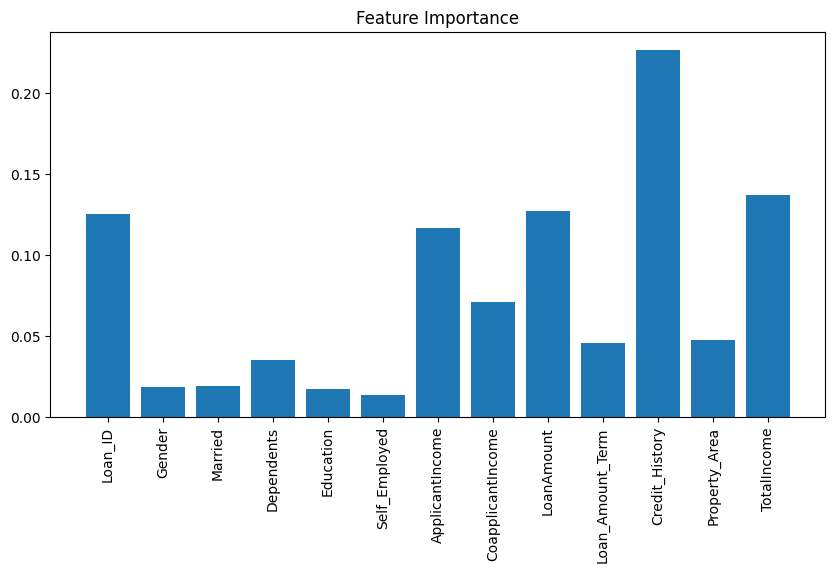

In [ ]:
importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()